In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [95]:
from google.colab import files

uploaded = files.upload()

Saving online+retail.zip to online+retail (2).zip


In [96]:
import zipfile
import os

zip_path = "/content/online+retail.zip"
extract_path = "/content/online_retail"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['Online Retail.xlsx']


In [97]:
import pandas as pd

file_path = "/content/online_retail/Online Retail.xlsx"

df = pd.read_excel(file_path)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [98]:
print(df.shape)

(541909, 8)


In [99]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [101]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [102]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [103]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [104]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

CustomerID     135080
Description      1454
dtype: int64


In [105]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

print(missing_percent)

CustomerID     24.926694
Description     0.268311
dtype: float64


In [106]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [107]:
df[df.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [108]:
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [109]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

Before removing duplicates: (541909, 8)
After removing duplicates: (536641, 8)


In [110]:
df = df.dropna(subset=['CustomerID'])

print("Shape after removing missing CustomerID:", df.shape)

Shape after removing missing CustomerID: (401604, 8)


In [111]:
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [112]:
print("Negative quantities:", (df['Quantity'] < 0).sum())
print("Zero quantities:", (df['Quantity'] == 0).sum())
print("Zero/negative prices:", (df['UnitPrice'] <= 0).sum())

Negative quantities: 8872
Zero quantities: 0
Zero/negative prices: 40


In [113]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [114]:
df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [115]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 401604
Columns: 9


In [116]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [117]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print("Shape after removing invalid sales:", df.shape)

Shape after removing invalid sales: (392692, 9)


In [118]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [119]:
print(df['InvoiceDate'].dtype)

datetime64[ns]


In [120]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

In [121]:
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

In [122]:
df[['InvoiceDate', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek']].head()

,InvoiceDate,Year,Month,Day,Hour,DayOfWeek
0,2010-12-01 08:26:00,2010,12,1,8,Wednesday
1,2010-12-01 08:26:00,2010,12,1,8,Wednesday
2,2010-12-01 08:26:00,2010,12,1,8,Wednesday
3,2010-12-01 08:26:00,2010,12,1,8,Wednesday
4,2010-12-01 08:26:00,2010,12,1,8,Wednesday


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   Revenue      392692 non-null  float64       
 9   Year         392692 non-null  int32         
 10  Month        392692 non-null  int32         
 11  Day          392692 non-null  int32         
 12  Hour         392692 non-null  int32         
 13  DayOfWeek    392692 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(4), int64(1), object(5)
memory usage: 38.9+ MB


In [124]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Wednesday


In [125]:
print(df.shape)

(392692, 14)


In [126]:
total_revenue = df['Revenue'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 8887208.894


In [127]:
total_orders = df['InvoiceNo'].nunique()

print("Total Orders:", total_orders)

Total Orders: 18532


In [128]:
total_customers = df['CustomerID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 4338


In [129]:
average_order_value = total_revenue / total_orders

print("Average Order Value:", average_order_value)

Average Order Value: 479.56016047917115


In [130]:
monthly_revenue = df.groupby(
    df['InvoiceDate'].dt.to_period('M')
)['Revenue'].sum()

print(monthly_revenue)

InvoiceDate
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64


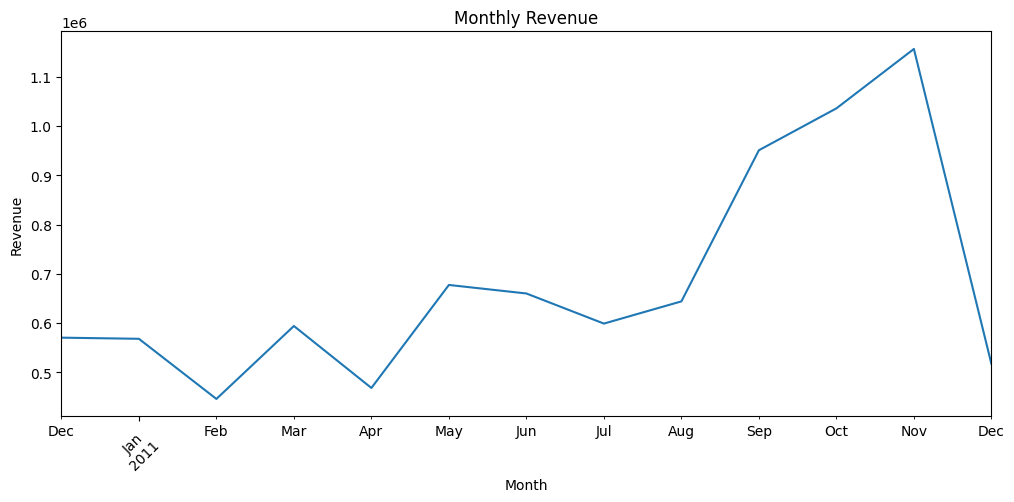

In [131]:
plt.figure(figsize=(12, 5))

monthly_revenue.plot()

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.show()

In [132]:
top_products = (
    df.groupby('Description')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64


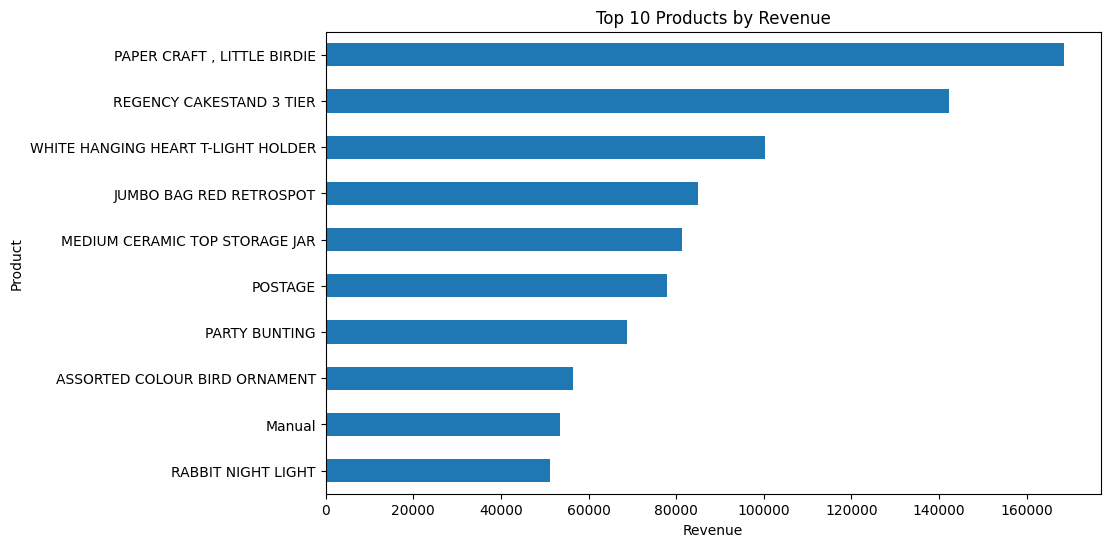

In [133]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

In [134]:
country_revenue = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(country_revenue)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64


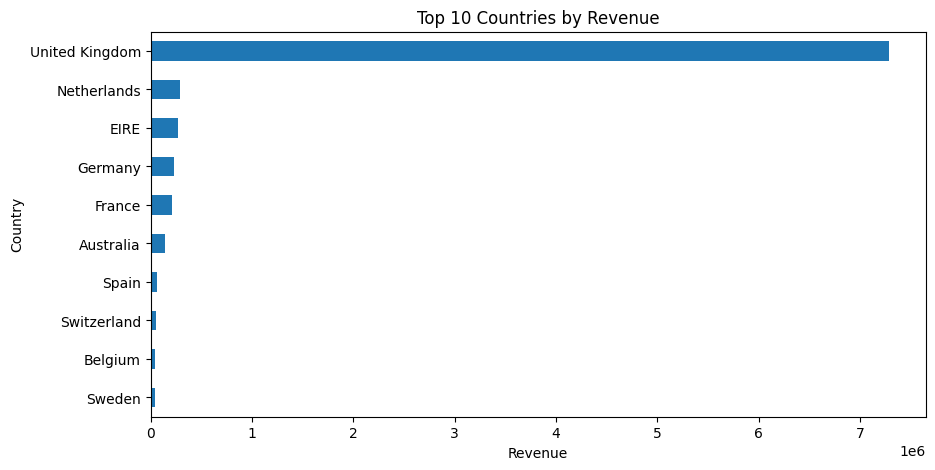

In [135]:
plt.figure(figsize=(10, 5))

country_revenue.sort_values().plot(kind='barh')

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

In [136]:
customer_revenue = (
    df.groupby('CustomerID')['Revenue']
      .sum()
      .sort_values(ascending=False)
)

print(customer_revenue.head(10))

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64


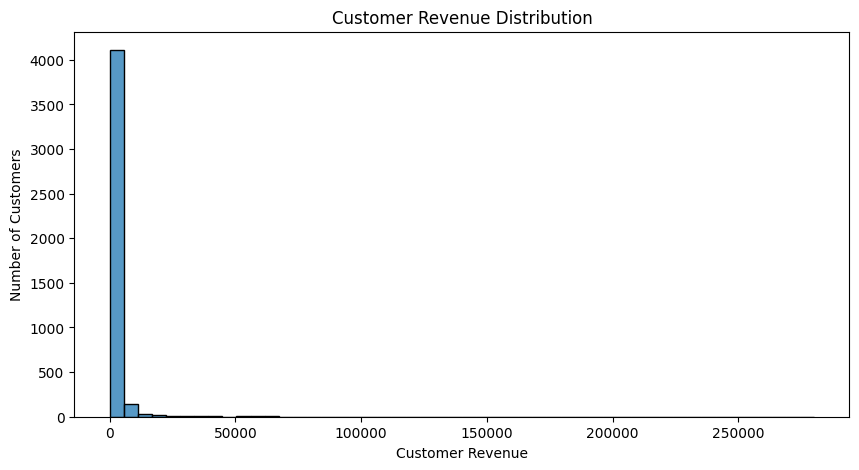

In [137]:
plt.figure(figsize=(10, 5))

sns.histplot(customer_revenue, bins=50)

plt.title("Customer Revenue Distribution")
plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers")

plt.show()

In [138]:
day_revenue = (
    df.groupby('DayOfWeek')['Revenue']
      .sum()
)

In [139]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_revenue = day_revenue.reindex(day_order)

print(day_revenue)


DayOfWeek
Monday       1363604.401
Tuesday      1697733.801
Wednesday    1584283.830
Thursday     1973015.730
Friday       1483080.811
Saturday             NaN
Sunday        785490.321
Name: Revenue, dtype: float64


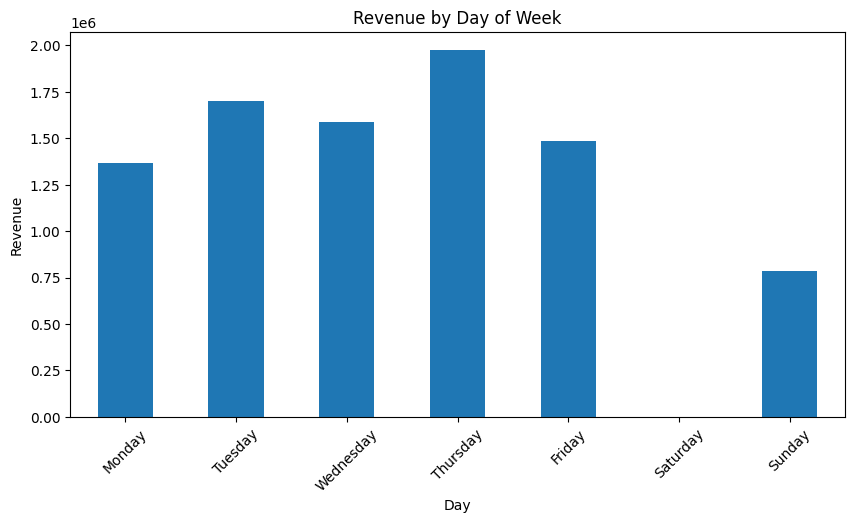

In [140]:
plt.figure(figsize=(10, 5))

day_revenue.plot(kind='bar')

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.show()

In [141]:
latest_date = df['InvoiceDate'].max()

print("Latest transaction date:", latest_date)

Latest transaction date: 2011-12-09 12:50:00


In [142]:
customer_recency = (
    df.groupby('CustomerID')['InvoiceDate']
      .max()
      .reset_index()
)

In [143]:
customer_recency.columns = ['CustomerID', 'LastPurchaseDate']

In [144]:
customer_recency['Recency'] = (
    latest_date - customer_recency['LastPurchaseDate']
).dt.days

In [145]:
customer_recency.head()

,CustomerID,LastPurchaseDate,Recency
0,12346.0,2011-01-18 10:01:00,325
1,12347.0,2011-12-07 15:52:00,1
2,12348.0,2011-09-25 13:13:00,74
3,12349.0,2011-11-21 09:51:00,18
4,12350.0,2011-02-02 16:01:00,309


In [146]:
customer_frequency = (
    df.groupby('CustomerID')['InvoiceNo']
      .nunique()
      .reset_index()
)

In [147]:
customer_frequency.columns = ['CustomerID', 'Frequency']

In [148]:
customer_monetary = (
    df.groupby('CustomerID')['Revenue']
      .sum()
      .reset_index()
)

In [149]:
customer_monetary.columns = ['CustomerID', 'Monetary']

In [150]:
customer_monetary.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [151]:
rfm = customer_recency.merge(
    customer_frequency,
    on='CustomerID'
)

rfm = rfm.merge(
    customer_monetary,
    on='CustomerID'
)

In [152]:
rfm.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary
0,12346.0,2011-01-18 10:01:00,325,1,77183.60
1,12347.0,2011-12-07 15:52:00,1,7,4310.00
2,12348.0,2011-09-25 13:13:00,74,4,1797.24
3,12349.0,2011-11-21 09:51:00,18,1,1757.55
4,12350.0,2011-02-02 16:01:00,309,1,334.40


In [153]:
rfm = rfm.drop(columns=['LastPurchaseDate'])

In [154]:
print(rfm.shape)
rfm.head()

(4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


In [155]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


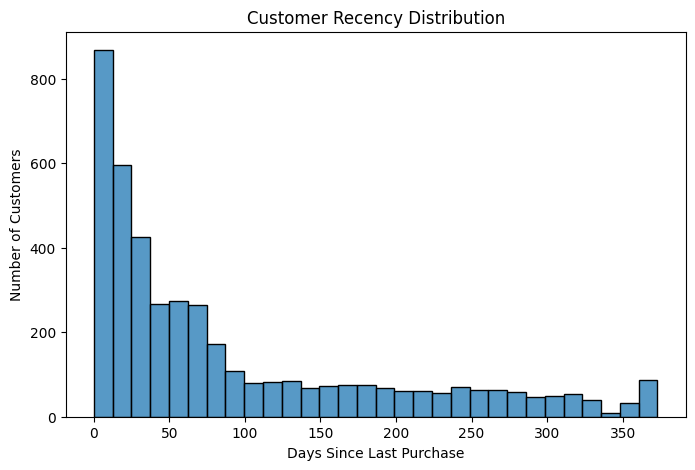

In [156]:
plt.figure(figsize=(8, 5))

sns.histplot(rfm['Recency'], bins=30)

plt.title("Customer Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.show()

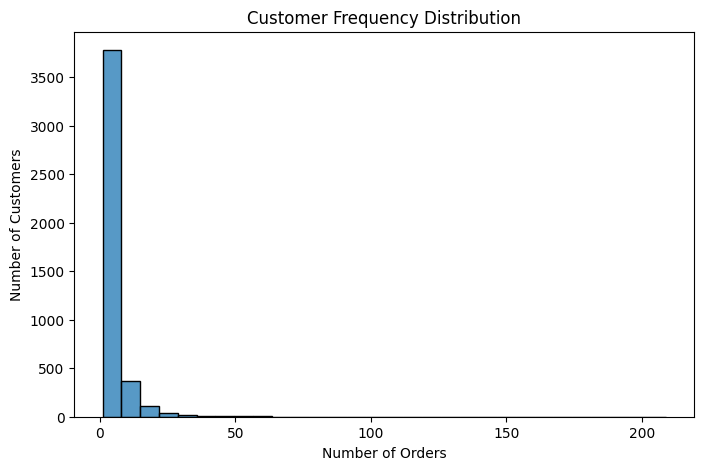

In [157]:
plt.figure(figsize=(8, 5))

sns.histplot(rfm['Frequency'], bins=30)

plt.title("Customer Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

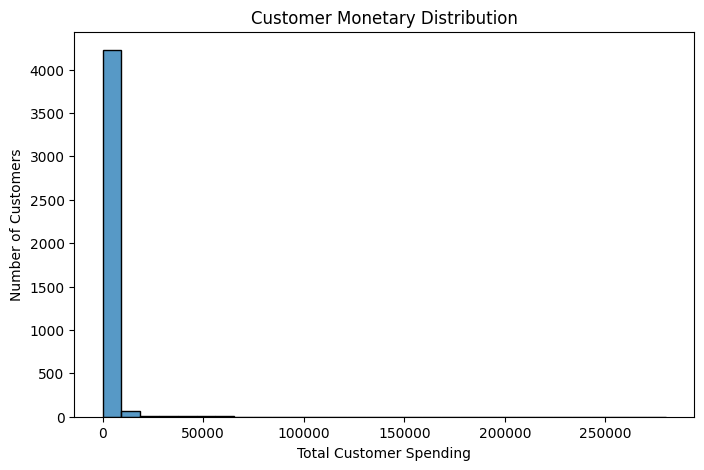

In [158]:
plt.figure(figsize=(8, 5))

sns.histplot(rfm['Monetary'], bins=30)

plt.title("Customer Monetary Distribution")
plt.xlabel("Total Customer Spending")
plt.ylabel("Number of Customers")

plt.show()

In [159]:
X_rfm = rfm[['Recency', 'Frequency', 'Monetary']]

In [160]:
X_rfm.head()

,Recency,Frequency,Monetary
0,325,1,77183.60
1,1,7,4310.00
2,74,4,1797.24
3,18,1,1757.55
4,309,1,334.40


In [161]:
print(X_rfm.describe())

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     91.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       0.000000     1.000000       3.750000
25%      17.000000     1.000000     306.482500
50%      50.000000     2.000000     668.570000
75%     141.000000     5.000000    1660.597500
max     373.000000   209.000000  280206.020000


In [162]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_rfm_scaled = scaler.fit_transform(X_rfm)

In [163]:
print(X_rfm_scaled[:5])

[[ 2.33457414 -0.4250965   8.36301037]
 [-0.90534032  0.3544168   0.2516989 ]
 [-0.17535959 -0.03533985 -0.02798783]
 [-0.73534481 -0.4250965  -0.03240559]
 [ 2.17457836 -0.4250965  -0.19081155]]


In [164]:
from sklearn.cluster import KMeans

In [165]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_rfm_scaled)

    inertia.append(kmeans.inertia_)

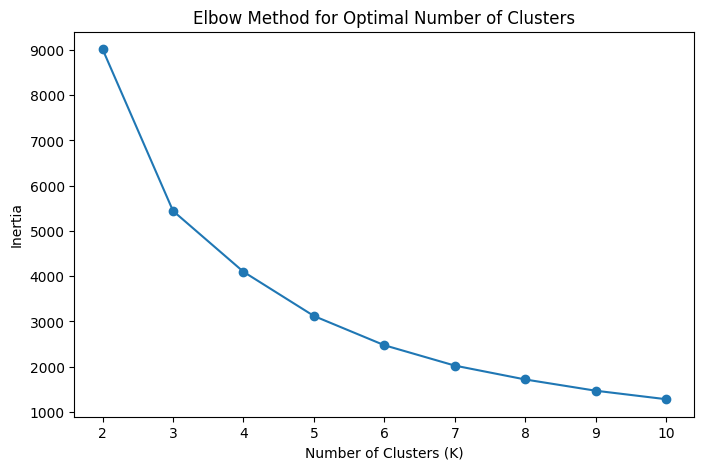

In [166]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [167]:
for i in range(len(inertia)):
    print(f"K = {i + 2}, Inertia = {inertia[i]:.2f}")

K = 2, Inertia = 9014.57
K = 3, Inertia = 5441.32
K = 4, Inertia = 4096.30
K = 5, Inertia = 3119.79
K = 6, Inertia = 2473.79
K = 7, Inertia = 2023.59
K = 8, Inertia = 1717.01
K = 9, Inertia = 1468.79
K = 10, Inertia = 1281.05


In [168]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(X_rfm_scaled)

In [169]:
print(rfm['Cluster'].value_counts().sort_index())

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


In [170]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).round(2)

print(cluster_summary)

         Recency  Frequency   Monetary  CustomerID
Cluster                                           
0          42.70       3.68    1353.63        3054
1         247.08       1.55     478.85        1067
2           6.38      82.54  127187.96          13
3          14.50      22.33   12690.50         204


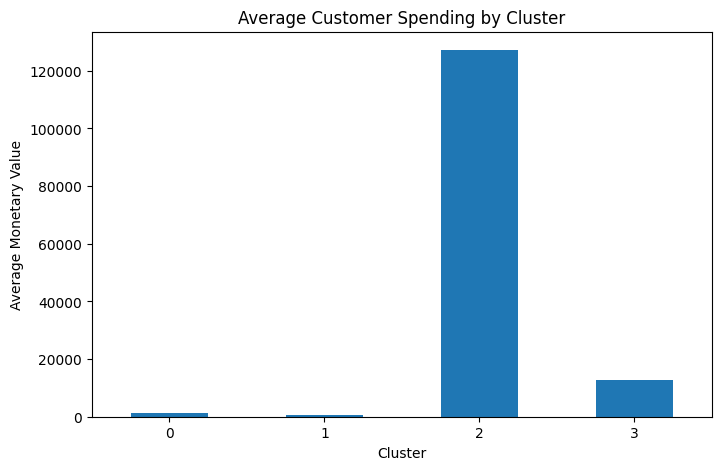

In [171]:
cluster_summary['Monetary'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Average Customer Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Monetary Value")

plt.xticks(rotation=0)
plt.show()

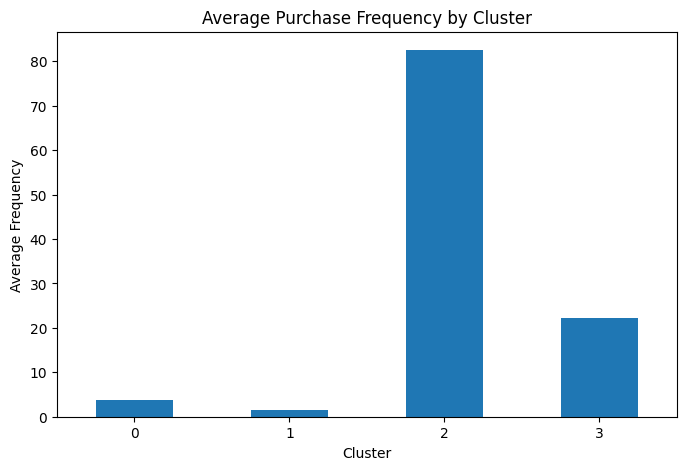

In [172]:
cluster_summary['Frequency'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Average Purchase Frequency by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Frequency")

plt.xticks(rotation=0)
plt.show()

In [173]:

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_rfm_scaled)

    score = silhouette_score(X_rfm_scaled, labels)
    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.8958
K = 3, Silhouette Score = 0.5942
K = 4, Silhouette Score = 0.6162
K = 5, Silhouette Score = 0.6165
K = 6, Silhouette Score = 0.5983
K = 7, Silhouette Score = 0.5165
K = 8, Silhouette Score = 0.4859


In [174]:
cluster_names = {
    0: 'Regular Customers',
    1: 'Inactive Customers',
    2: 'VIP Customers',
    3: 'Loyal High-Value Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,325,1,77183.60,3,Loyal High-Value Customers
1,12347.0,1,7,4310.00,0,Regular Customers
2,12348.0,74,4,1797.24,0,Regular Customers
3,12349.0,18,1,1757.55,0,Regular Customers
4,12350.0,309,1,334.40,1,Inactive Customers
5,12352.0,35,8,2506.04,0,Regular Customers
6,12353.0,203,1,89.00,1,Inactive Customers
7,12354.0,231,1,1079.40,1,Inactive Customers
8,12355.0,213,1,459.40,1,Inactive Customers
9,12356.0,22,3,2811.43,0,Regular Customers


In [175]:
segment_summary = rfm.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

print(segment_summary)

                            Customers  Avg_Recency  Avg_Frequency  \
Segment                                                             
Inactive Customers               1067       247.08           1.55   
Loyal High-Value Customers        204        14.50          22.33   
Regular Customers                3054        42.70           3.68   
VIP Customers                      13         6.38          82.54   

                            Avg_Monetary  
Segment                                   
Inactive Customers                478.85  
Loyal High-Value Customers      12690.50  
Regular Customers                1353.63  
VIP Customers                  127187.96  


In [176]:
segment_summary['Customer_Percentage'] = (
    segment_summary['Customers'] / len(rfm) * 100
).round(2)

print(segment_summary)

                            Customers  Avg_Recency  Avg_Frequency  \
Segment                                                             
Inactive Customers               1067       247.08           1.55   
Loyal High-Value Customers        204        14.50          22.33   
Regular Customers                3054        42.70           3.68   
VIP Customers                      13         6.38          82.54   

                            Avg_Monetary  Customer_Percentage  
Segment                                                        
Inactive Customers                478.85                 24.6  
Loyal High-Value Customers      12690.50                  4.7  
Regular Customers                1353.63                 70.4  
VIP Customers                  127187.96                  0.3  


In [177]:
segment_summary['Customer_Percentage'] = (
    segment_summary['Customers'] / len(rfm) * 100
).round(2)

print(segment_summary)

                            Customers  Avg_Recency  Avg_Frequency  \
Segment                                                             
Inactive Customers               1067       247.08           1.55   
Loyal High-Value Customers        204        14.50          22.33   
Regular Customers                3054        42.70           3.68   
VIP Customers                      13         6.38          82.54   

                            Avg_Monetary  Customer_Percentage  
Segment                                                        
Inactive Customers                478.85                 24.6  
Loyal High-Value Customers      12690.50                  4.7  
Regular Customers                1353.63                 70.4  
VIP Customers                  127187.96                  0.3  


In [178]:
print("Start date:", df['InvoiceDate'].min())
print("End date:", df['InvoiceDate'].max())

Start date: 2010-12-01 08:26:00
End date: 2011-12-09 12:50:00


In [179]:
start_date = df['InvoiceDate'].min()
end_date = df['InvoiceDate'].max()

cutoff_date = start_date + pd.Timedelta(days=270)
future_end_date = end_date

print("Start date:", start_date)
print("Feature cutoff:", cutoff_date)
print("End date:", future_end_date)

Start date: 2010-12-01 08:26:00
Feature cutoff: 2011-08-28 08:26:00
End date: 2011-12-09 12:50:00


In [180]:
historical_df = df[df['InvoiceDate'] < cutoff_date].copy()

future_df = df[df['InvoiceDate'] >= cutoff_date].copy()

print("Historical transactions:", historical_df.shape)
print("Future transactions:", future_df.shape)

Historical transactions: (221745, 14)
Future transactions: (170947, 14)


In [181]:
customer_features = historical_df.groupby('CustomerID').agg(
    TotalSpend=('Revenue', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique'),
    TotalItems=('Quantity', 'sum'),
    AverageOrderValue=('Revenue', 'mean'),
    AverageItemPrice=('UnitPrice', 'mean'),
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max')
).reset_index()

In [182]:
customer_features['Recency'] = (
    cutoff_date - customer_features['LastPurchase']
).dt.days

In [183]:
customer_features['CustomerLifetime'] = (
    customer_features['LastPurchase'] -
    customer_features['FirstPurchase']
).dt.days

In [184]:
customer_features.head()

,CustomerID,TotalSpend,TotalOrders,TotalItems,AverageOrderValue,AverageItemPrice,FirstPurchase,LastPurchase,Recency,CustomerLifetime
0,12346.0,77183.60,1,74215,77183.600000,1.040000,2011-01-18 10:01:00,2011-01-18 10:01:00,221,0
1,12347.0,2790.86,5,1590,22.506935,2.797661,2010-12-07 14:57:00,2011-08-02 08:48:00,25,237
2,12348.0,1487.24,3,2124,53.115714,4.864643,2010-12-16 19:09:00,2011-04-05 10:47:00,144,109
3,12350.0,334.40,1,197,19.670588,3.841176,2011-02-02 16:01:00,2011-02-02 16:01:00,206,0
4,12352.0,1561.81,5,254,41.100263,27.449474,2011-02-16 12:33:00,2011-03-22 16:08:00,158,34


In [185]:
future_spend = (
    future_df.groupby('CustomerID')['Revenue']
    .sum()
    .reset_index()
)

future_spend.columns = ['CustomerID', 'FutureSpend']

print(future_spend.head())

   CustomerID  FutureSpend
0     12347.0      1519.14
1     12348.0       310.00
2     12349.0      1757.55
3     12352.0       944.23
4     12356.0        58.35


In [186]:
ml_data = customer_features.merge(
    future_spend,
    on='CustomerID',
    how='left'
)

ml_data['FutureSpend'] = ml_data['FutureSpend'].fillna(0)

ml_data.head()

,CustomerID,TotalSpend,TotalOrders,TotalItems,AverageOrderValue,AverageItemPrice,FirstPurchase,LastPurchase,Recency,CustomerLifetime,FutureSpend
0,12346.0,77183.60,1,74215,77183.600000,1.040000,2011-01-18 10:01:00,2011-01-18 10:01:00,221,0,0.00
1,12347.0,2790.86,5,1590,22.506935,2.797661,2010-12-07 14:57:00,2011-08-02 08:48:00,25,237,1519.14
2,12348.0,1487.24,3,2124,53.115714,4.864643,2010-12-16 19:09:00,2011-04-05 10:47:00,144,109,310.00
3,12350.0,334.40,1,197,19.670588,3.841176,2011-02-02 16:01:00,2011-02-02 16:01:00,206,0,0.00
4,12352.0,1561.81,5,254,41.100263,27.449474,2011-02-16 12:33:00,2011-03-22 16:08:00,158,34,944.23


In [187]:
spenders = ml_data.loc[
    ml_data['FutureSpend'] > 0,
    'FutureSpend'
]

high_value_threshold = spenders.quantile(0.75)

print("High-value threshold:", high_value_threshold)

High-value threshold: 1259.605


In [188]:
ml_data['HighValueFuture'] = (
    ml_data['FutureSpend'] >= high_value_threshold
).astype(int)

print(ml_data['HighValueFuture'].value_counts())

HighValueFuture
0    2814
1     491
Name: count, dtype: int64


In [189]:
features = [
    'TotalSpend',
    'TotalOrders',
    'TotalItems',
    'AverageOrderValue',
    'AverageItemPrice',
    'Recency',
    'CustomerLifetime'
]

X = ml_data[features]
y = ml_data['HighValueFuture']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (3305, 7)
y shape: (3305,)

Target distribution:
HighValueFuture
0    2814
1     491
Name: count, dtype: int64


In [190]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2644, 7)
Testing data: (661, 7)


In [191]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(random_state=42))])

In [192]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [193]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8986384266263238

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       563
           1       0.86      0.38      0.52        98

    accuracy                           0.90       661
   macro avg       0.88      0.68      0.73       661
weighted avg       0.90      0.90      0.88       661



[[557   6]
 [ 61  37]]


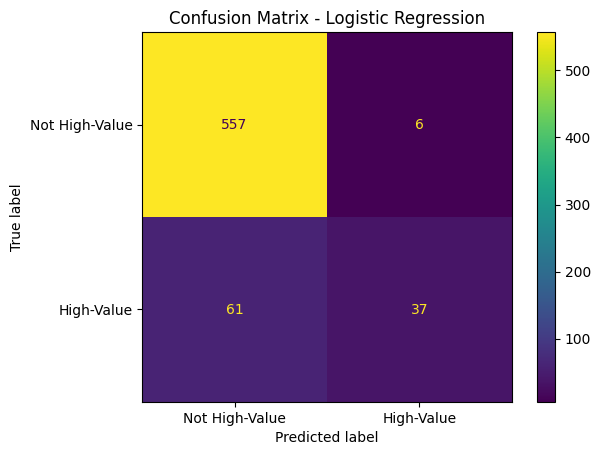

In [194]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not High-Value', 'High-Value']
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [195]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8512705259723783


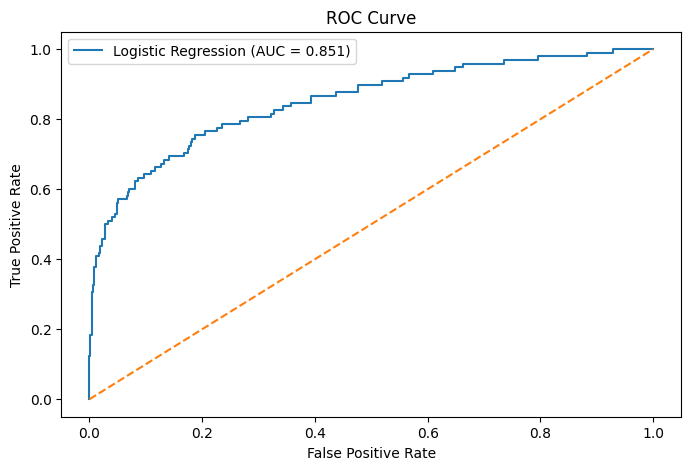

In [196]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [197]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [198]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9001512859304085

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       563
           1       0.78      0.46      0.58        98

    accuracy                           0.90       661
   macro avg       0.84      0.72      0.76       661
weighted avg       0.89      0.90      0.89       661



In [199]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.8455341283938087


In [200]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Logistic Regression metrics
lr_pred = model.predict(X_test)
lr_prob = model.predict_proba(X_test)[:, 1]

# Random Forest metrics
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

print(results.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8986     0.8605  0.3776    0.5248   0.8513
1        Random Forest    0.9002     0.7759  0.4592    0.5769   0.8455


In [201]:
from xgboost import XGBClassifier

In [202]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [203]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost Accuracy :", round(xgb_accuracy, 4))
print("XGBoost Precision:", round(xgb_precision, 4))
print("XGBoost Recall   :", round(xgb_recall, 4))
print("XGBoost F1 Score :", round(xgb_f1, 4))
print("XGBoost ROC-AUC  :", round(xgb_auc, 4))

XGBoost Accuracy : 0.9002
XGBoost Precision: 0.7759
XGBoost Recall   : 0.4592
XGBoost F1 Score : 0.5769
XGBoost ROC-AUC  : 0.8463


In [204]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       563
           1       0.78      0.46      0.58        98

    accuracy                           0.90       661
   macro avg       0.84      0.72      0.76       661
weighted avg       0.89      0.90      0.89       661



In [205]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_cv = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring='f1'
)

rf_cv = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring='f1'
)

xgb_cv = cross_val_score(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring='f1'
)

print("Logistic Regression F1:", lr_cv)
print("Mean:", lr_cv.mean())

print("\nRandom Forest F1:", rf_cv)
print("Mean:", rf_cv.mean())

print("\nXGBoost F1:", xgb_cv)
print("Mean:", xgb_cv.mean())

Logistic Regression F1: [0.57534247 0.54545455 0.48571429 0.58503401 0.59210526]
Mean: 0.5567301147371186

Random Forest F1: [0.62745098 0.58227848 0.55128205 0.59602649 0.65408805]
Mean: 0.6022252106135114

XGBoost F1: [0.6375     0.59259259 0.55421687 0.5974026  0.6375    ]
Mean: 0.6038424114930139


In [206]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

rf_params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 5, 10, 15],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest CV F1:")
print(rf_search.best_score_)

Best Random Forest parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 15}

Best CV F1:
0.6354935547710742


In [207]:
RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced'
)

RandomForestClassifier(class_weight='balanced', n_estimators=200)

In [208]:
from xgboost import XGBClassifier

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    xgb_params,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest CV F1:")
print(xgb_search.best_score_)

Best XGBoost parameters:
{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best CV F1:
0.6143455512558518


In [209]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

best_xgb = xgb_search.best_estimator_

tuned_xgb_pred = best_xgb.predict(X_test)
tuned_xgb_prob = best_xgb.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, tuned_xgb_pred)
tuned_precision = precision_score(y_test, tuned_xgb_pred)
tuned_recall = recall_score(y_test, tuned_xgb_pred)
tuned_f1 = f1_score(y_test, tuned_xgb_pred)
tuned_auc = roc_auc_score(y_test, tuned_xgb_prob)

print("Tuned XGBoost Accuracy :", round(tuned_accuracy, 4))
print("Tuned XGBoost Precision:", round(tuned_precision, 4))
print("Tuned XGBoost Recall   :", round(tuned_recall, 4))
print("Tuned XGBoost F1 Score :", round(tuned_f1, 4))
print("Tuned XGBoost ROC-AUC  :", round(tuned_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, tuned_xgb_pred))

Tuned XGBoost Accuracy : 0.9062
Tuned XGBoost Precision: 0.8214
Tuned XGBoost Recall   : 0.4694
Tuned XGBoost F1 Score : 0.5974
Tuned XGBoost ROC-AUC  : 0.8667

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95       563
           1       0.82      0.47      0.60        98

    accuracy                           0.91       661
   macro avg       0.87      0.73      0.77       661
weighted avg       0.90      0.91      0.90       661



In [210]:
import joblib

joblib.dump(best_xgb, 'xgboost_high_value_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [211]:
import os

print(os.path.exists('xgboost_high_value_model.pkl'))

True


In [212]:
model = joblib.load('xgboost_high_value_model.pkl')

In [213]:
features = [
    'TotalSpend',
    'TotalOrders',
    'TotalItems',
    'AverageOrderValue',
    'AverageItemPrice',
    'Recency',
    'CustomerLifetime'
]

In [214]:
joblib.dump(features, 'features.pkl')

print("Features saved successfully!")

Features saved successfully!


In [215]:
print(joblib.load('features.pkl'))

['TotalSpend', 'TotalOrders', 'TotalItems', 'AverageOrderValue', 'AverageItemPrice', 'Recency', 'CustomerLifetime']


In [216]:
app_code = '''
import streamlit as st
import pandas as pd
import joblib

# Load model and features
model = joblib.load("xgboost_high_value_model.pkl")
features = joblib.load("features.pkl")

# Page title
st.title("Retail Customer Intelligence System")

st.write(
    "Predict whether a customer is likely to become a high-value customer "
    "based on their historical purchasing behavior."
)

st.divider()

st.subheader("Enter Customer Information")

# Customer inputs
total_spend = st.number_input(
    "Total Spend",
    min_value=0.0,
    value=1000.0
)

total_orders = st.number_input(
    "Total Orders",
    min_value=1,
    value=5
)

total_items = st.number_input(
    "Total Items Purchased",
    min_value=1,
    value=20
)

average_order_value = st.number_input(
    "Average Order Value",
    min_value=0.0,
    value=200.0
)

average_item_price = st.number_input(
    "Average Item Price",
    min_value=0.0,
    value=10.0
)

recency = st.number_input(
    "Recency (Days Since Last Purchase)",
    min_value=0,
    value=30
)

customer_lifetime = st.number_input(
    "Customer Lifetime (Days)",
    min_value=0,
    value=100
)

# Create input dataframe
input_data = pd.DataFrame([[
    total_spend,
    total_orders,
    total_items,
    average_order_value,
    average_item_price,
    recency,
    customer_lifetime
]], columns=features)

# Prediction
if st.button("Predict Customer Value"):

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    st.subheader("Prediction")

    if prediction == 1:
        st.success("High-Value Customer")
    else:
        st.info("Not High-Value Customer")

    st.write(
        f"Probability of becoming a high-value customer: "
        f"{probability:.2%}"
    )
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [217]:
import os

print("app.py:", os.path.exists("app.py"))
print("model:", os.path.exists("xgboost_high_value_model.pkl"))
print("features:", os.path.exists("features.pkl"))

app.py: True
model: True
features: True


In [218]:
print("app.py:", os.path.exists("app.py"))
print("model:", os.path.exists("xgboost_high_value_model.pkl"))
print("features:", os.path.exists("features.pkl"))

app.py: True
model: True
features: True


In [219]:
sql_code = '''
-- Retail Business Intelligence SQL Analysis

-- 1. Total Revenue
SELECT
    SUM(Quantity * UnitPrice) AS Total_Revenue
FROM online_retail;


-- 2. Total Orders
SELECT
    COUNT(DISTINCT InvoiceNo) AS Total_Orders
FROM online_retail;


-- 3. Total Customers
SELECT
    COUNT(DISTINCT CustomerID) AS Total_Customers
FROM online_retail;


-- 4. Average Order Value
SELECT
    SUM(Quantity * UnitPrice) / COUNT(DISTINCT InvoiceNo)
        AS Average_Order_Value
FROM online_retail;


-- 5. Top 10 Products by Revenue
SELECT
    Description,
    SUM(Quantity * UnitPrice) AS Revenue
FROM online_retail
GROUP BY Description
ORDER BY Revenue DESC
LIMIT 10;


-- 6. Top 10 Countries by Revenue
SELECT
    Country,
    SUM(Quantity * UnitPrice) AS Revenue
FROM online_retail
GROUP BY Country
ORDER BY Revenue DESC
LIMIT 10;


-- 7. Customer Revenue
SELECT
    CustomerID,
    SUM(Quantity * UnitPrice) AS Customer_Revenue
FROM online_retail
GROUP BY CustomerID
ORDER BY Customer_Revenue DESC
LIMIT 10;


-- 8. Monthly Revenue
SELECT
    EXTRACT(YEAR FROM InvoiceDate) AS Year,
    EXTRACT(MONTH FROM InvoiceDate) AS Month,
    SUM(Quantity * UnitPrice) AS Revenue
FROM online_retail
GROUP BY
    EXTRACT(YEAR FROM InvoiceDate),
    EXTRACT(MONTH FROM InvoiceDate)
ORDER BY Year, Month;


-- 9. Revenue by Country
SELECT
    Country,
    SUM(Quantity * UnitPrice) AS Revenue
FROM online_retail
GROUP BY Country
ORDER BY Revenue DESC;


-- 10. Number of Orders per Customer
SELECT
    CustomerID,
    COUNT(DISTINCT InvoiceNo) AS Number_of_Orders
FROM online_retail
GROUP BY CustomerID
ORDER BY Number_of_Orders DESC;
'''

with open("analysis.sql", "w") as f:
    f.write(sql_code)

print("analysis.sql created successfully!")

analysis.sql created successfully!


In [220]:
import os

print("analysis.sql:", os.path.exists("analysis.sql"))

analysis.sql: True


In [221]:
requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
openpyxl
streamlit
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!
